**X Data Sentiment Analysis**

*Sentiment Analysis refers to the detection of emotional tone (happy,sad,anger,frustated) within text through Natural Language Processing or Machine Learning Model*



***Importing the required Dependencies for Analysis***

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

***Importing X Sentiment Dataset***

In [4]:
x_data = pd.read_csv("X data.csv", encoding='ISO 8859-1')

***Cheking shape of data that representing number of rows and columns available in data***

In [5]:
x_data.shape

(162980, 2)

***Checking top 5 rows and columns of dataset to undderstand features available in data***


In [6]:
x_data.head()

,clean_text,category
0,when modi promised âminimum government maxim...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


**Exploratory Data Analysis**

*EDA refers to the process of exploring or analysing data to uncover trends,pattern and insights from data.*

***Checking for missing values in data***

In [7]:
x_data.isnull().sum()

clean_text    4
category      7
dtype: int64

**Checking Sentiment Distribution**

In [8]:
x_data['category'].value_counts()

category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64

***As we have very less missing value in the data so we will drop the null values***

In [9]:
x_data.dropna(inplace=True)

In [10]:
print("Duplicated rows:", x_data.duplicated().sum())
x_data.drop_duplicates()

Duplicated rows: 1


,clean_text,category
0,when modi promised âminimum government maxim...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0
...,...,...
162975,why these 456 crores paid neerav modi not reco...,-1.0
162976,dear rss terrorist payal gawar what about modi...,-1.0
162977,did you cover her interaction forum where she ...,0.0
162978,there big project came into india modi dream p...,0.0


***Visualizing Sentiment Distribution***

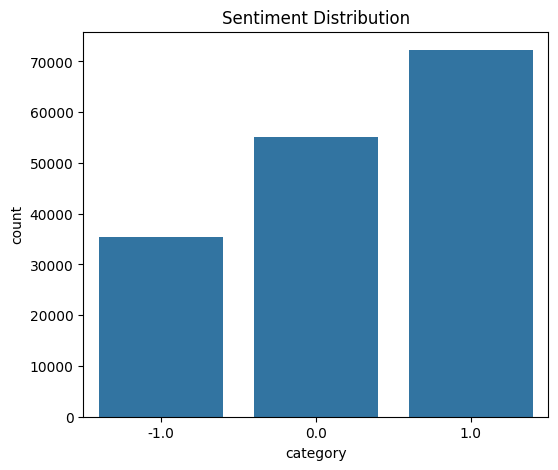

In [11]:
plt.figure(figsize=(6,5))
sns.countplot(x='category',data=x_data)

plt.title("Sentiment Distribution")
plt.show()

***Pie Chart***

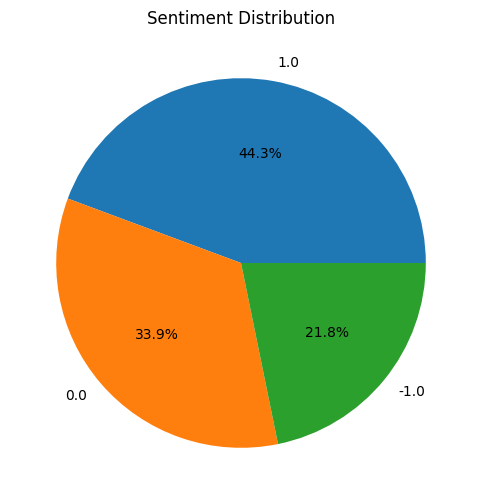

In [12]:
x_data['category'].value_counts().plot(kind = 'pie',figsize=(6,6),autopct = '%1.1f%%')
plt.ylabel('')
plt.title("Sentiment Distribution")
plt.show()

**Word Cloud provide a vissual summary of most frequently used words within a specific emotional category(positive and negative)**

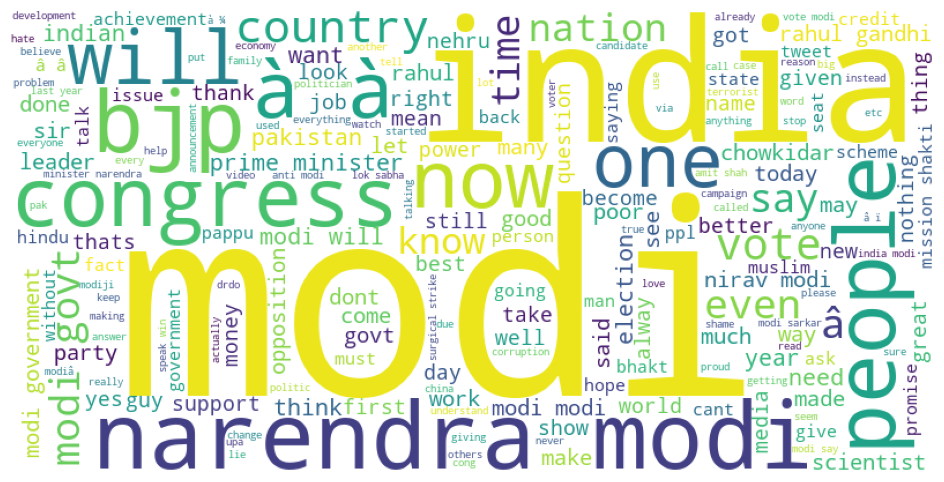

In [13]:
from wordcloud import WordCloud

text = " ".join(x_data['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

***Word Cloud help us to understand frequency or importace of word according to the size, here modi and india are most used words in tweets so analyst will easily understand that tweet data is related with political matter***

**As The dataset already contained a preprocessed clean_text column. Therefore, additional stemming and lemmatization were not applied, as the text had already been normalized. The cleaned text was directly converted into TF-IDF features for model training.**

***Feature Extraction (TF-IDF)***

In [14]:
X = x_data['clean_text']
y = x_data['category']
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(X)

In [15]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2978451 stored elements and shape (162969, 109430)>
  Coords	Values
  (0, 106342)	0.11261560434329192
  (0, 64007)	0.03272131057840136
  (0, 78809)	0.1604659951424217
  (0, 63133)	0.182315541945945
  (0, 41491)	0.12162101997244677
  (0, 61776)	0.20929872143252712
  (0, 41474)	0.31916315267064044
  (0, 35498)	0.19491132859660393
  (0, 45035)	0.11213042705836437
  (0, 13963)	0.22031452175262692
  (0, 97831)	0.10651607876412449
  (0, 30019)	0.19668474830381572
  (0, 52589)	0.14957427344719448
  (0, 82393)	0.30378576798164125
  (0, 93336)	0.30042532301462965
  (0, 106565)	0.10480973861081753
  (0, 31179)	0.140169188473833
  (0, 96131)	0.12932801708575764
  (0, 108143)	0.11612623155634574
  (0, 40334)	0.12157956649552974
  (0, 53237)	0.19605484179144825
  (0, 89954)	0.23046468053798785
  (0, 8516)	0.17942031980228298
  (0, 69658)	0.07860138567672283
  (0, 18300)	0.1747668846010603
  :	:
  (162968, 67472)	0.10546589103284763
  (16

***Till here we converted the text data into numerical values as machine learning model works on numerical data so that model can perform efficiently.***

**Splitting data into training and testing data**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 42)

**Training Different Machine Learning Model and Testing Accuracy**

**Naive Bayes**

In [17]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
print("Naive Bayes Accuracy:", accuracy_score(y_test, pred_nb))

Naive Bayes Accuracy: 0.5657482972326195


**Logistic Regression**

In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, pred_lr))

Logistic Regression Accuracy: 0.9190341780695833


**Support Vector Machine**

In [19]:
svm = LinearSVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

print("SVM Accuracy:",accuracy_score(y_test,pred_svm))

SVM Accuracy: 0.9431797263299994


**VADER(Valence Aware Dictionary and sEntiment Reasoner) lexicon and rule-based sentiment analysis.**

In [20]:
##Creating Vader Object
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\aryan\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [21]:
text = "modi government is doing worst day by day"
score = sia.polarity_scores(text)
print(score)

{'neg': 0.369, 'neu': 0.631, 'pos': 0.0, 'compound': -0.6249}


In [ ]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    x_data['clean_text'],
    x_data['category'],
    test_size=0.2,
    random_state=42
)
vader_pred= X_test_text.apply(lambda text: sia.polarity_scores(text)['compound'])

*Accuracy of VADER Model when trained on 80% data*

In [ ]:
vader_accuracy = accuracy_score(y_test, vader_pred)

print("Accuracy:", vader_accuracy)


Accuracy: 0.5675277658464748


In [ ]:
nb_accuracy = accuracy_score(y_test, pred_nb)

lr_accuracy = accuracy_score(y_test, pred_lr)

svm_accuracy = accuracy_score(y_test, pred_svm)

*Comparing accuracy of ML based Model and VADER based model*

In [ ]:
comparison = pd.DataFrame({

    'Model': [
        'VADER',
        'Naive Bayes',
        'Logistic Regression',
        'SVM'
        
    ],

    'Accuracy': [
        vader_accuracy,
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ]

})

comparison = comparison.sort_values(by='Accuracy', ascending=False)

print(comparison)

                 Model  Accuracy
3                  SVM  0.943180
2  Logistic Regression  0.919034
0                VADER  0.567528
1          Naive Bayes  0.565748


*Plotting Model Comparison*

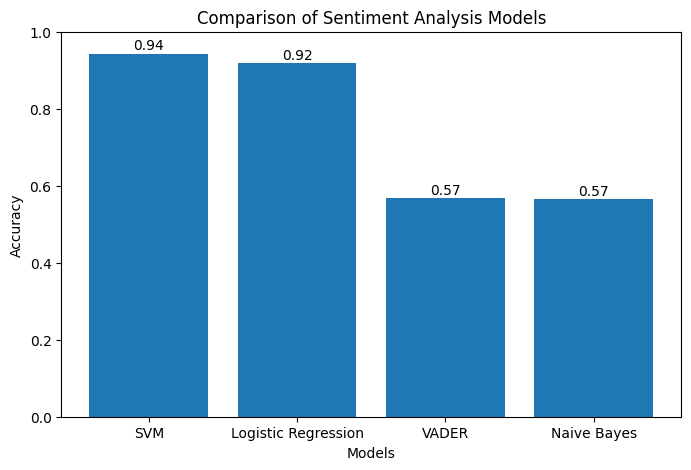

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(comparison['Model'], comparison['Accuracy'])

plt.xlabel('Models')
plt.ylabel("Accuracy")
plt.title("Comparison of Sentiment Analysis Models")

plt.ylim(0,1)

for i, value in enumerate(comparison['Accuracy']):
    plt.text(i, value + 0.01, f"{value:.2f}", ha='center')

plt.show()

*Predicting New Sentiment*

In [ ]:
sentence=(input("Enter Tweet : "))

text_vector= vectorizer.transform([sentence])

prediction=svm.predict(text_vector)

label={
-1:"Negative",
0:"Neutral",
1:"Positive"
}

print("ML Prediction :",label[prediction[0]])

score=sia.polarity_scores(sentence)["compound"]

if score>=0.05:
    print("VADER Prediction : Positive")

elif score<=-0.05:
    print("VADER Prediction : Negative")

else:
    print("VADER Prediction : Neutral")

ML Prediction : Neutral
VADER Prediction : Positive
